Load data

In [1]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

X = [[0],[1],[2],[3],[4],[5],[6],[7],[8],[9],[10],[11],[12],[13],[14],[15],[16],[17],[18]]
y = [0,0,0,0,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1]
thresholds = np.arange(0.0, 1.0, 1/18)


Train the model

In [2]:
model = LogisticRegression()
model.fit(X, y)

probs = model.predict_proba(X)[:, 1]  # probability of class 1

print(probs)

[0.00236158 0.0059661  0.01498957 0.03715063 0.08911126 0.19874545
 0.38609123 0.61458074 0.80170578 0.91111866 0.96295068 0.98505224
 0.9940507  0.99764509 0.99906989 0.99963295 0.9998552  0.99994289
 0.99997747]


In [3]:
def confusion_counts(y_true, y_pred):
    if len(y_true) != len(y_pred):
        raise ValueError("Arrays must have the same length")

    TP = TN = FP = FN = 0

    for t, p in zip(y_true, y_pred):
        if t == 1 and p == 1:
            TP += 1
        elif t == 0 and p == 0:
            TN += 1
        elif t == 0 and p == 1:
            FP += 1
        elif t == 1 and p == 0:
            FN += 1

    return TP, TN, FP, FN

tp = []
fp = []

for t in thresholds:
    y_pred_custom = (probs >= t).astype(int)
    TP, TN, FP, FN = confusion_counts(y, y_pred_custom)
    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)  #Sensitivity
    fp.append(FPR)
    tp.append(TPR)

[1.0, 0.42857142857142855, 0.2857142857142857, 0.2857142857142857, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9166666666666666, 0.9166666666666666, 0.9166666666666666, 0.9166666666666666, 0.9166666666666666, 0.9166666666666666, 0.9166666666666666, 0.9166666666666666, 0.8333333333333334, 0.8333333333333334, 0.75]


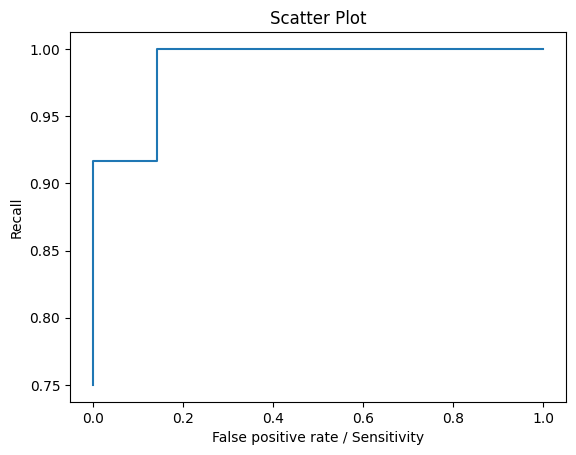

In [4]:
print(fp)
print(tp)
plt.plot(fp, tp)
plt.xlabel("False positive rate / Sensitivity")
plt.ylabel("Recall")
plt.title("Scatter Plot")
plt.show()